Dataset variables: ['tcw']
Selected tcw shape: (721, 1440)
tcw coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']


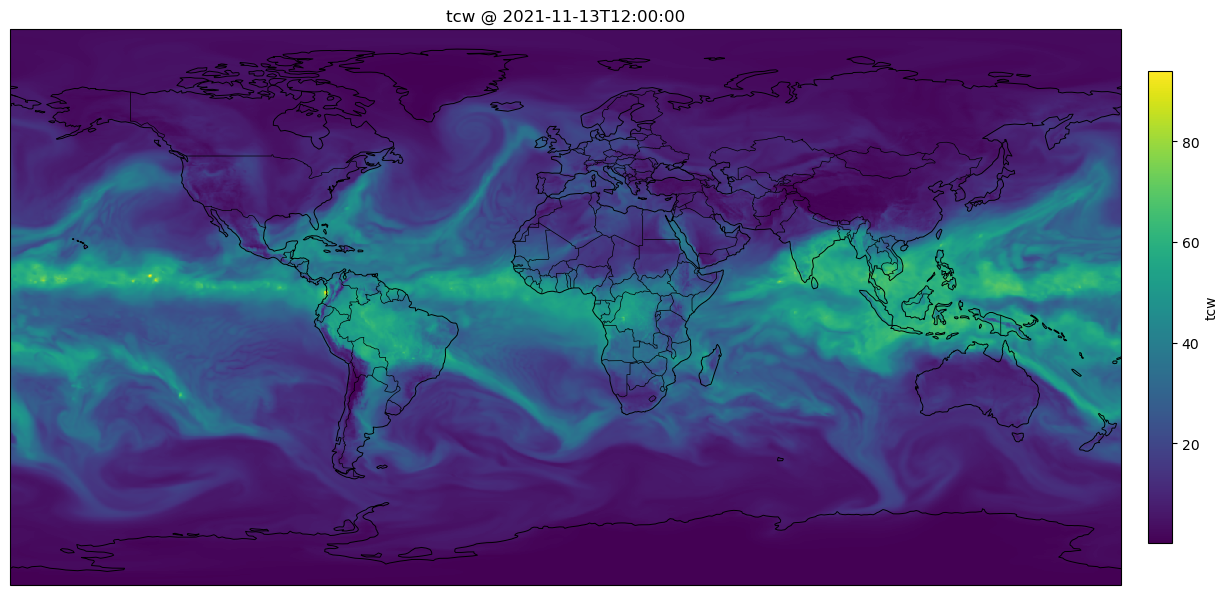

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- open dataset ----
PATH = "../data/waterTransport-instant.nc"
ds = xr.open_dataset(PATH)

# ---- select variable + time ----
# tcw is typically "total column water" (units often kg/m^2)
da = ds["tcw"]

t = np.datetime64("2021-11-13T12:00:00")

# Use exact match if present; otherwise this will error (which is usually what you want)
tcw = da.sel(valid_time=t)

# ---- quick sanity prints ----
print("Dataset variables:", list(ds.data_vars))
print("Selected tcw shape:", tcw.shape)
print("tcw coords:", list(tcw.coords))

# ---- plot ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

# Basic pcolormesh assumes lon/lat coordinate names; common: longitude/latitude or lon/lat
lon_name = "longitude" if "longitude" in tcw.coords else "lon"
lat_name = "latitude" if "latitude" in tcw.coords else "lat"

lon = tcw[lon_name].values
lat = tcw[lat_name].values
vals = tcw.values

mesh = ax.pcolormesh(lon, lat, vals, transform=ccrs.PlateCarree())

ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"tcw @ {str(t)}")

plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.85, label="tcw")
plt.tight_layout()
plt.show()

Dataset variables: ['tcw']
Selected tcw shape: (721, 1440)
tcw coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
vmin: 0.12883156538009644 vmax: 93.90812683105469
bin edges: [ 0.12883157  9.50676109 18.88469062 28.26262015 37.64054967 47.0184792
 56.39640872 65.77433825 75.15226778 84.5301973  93.90812683]


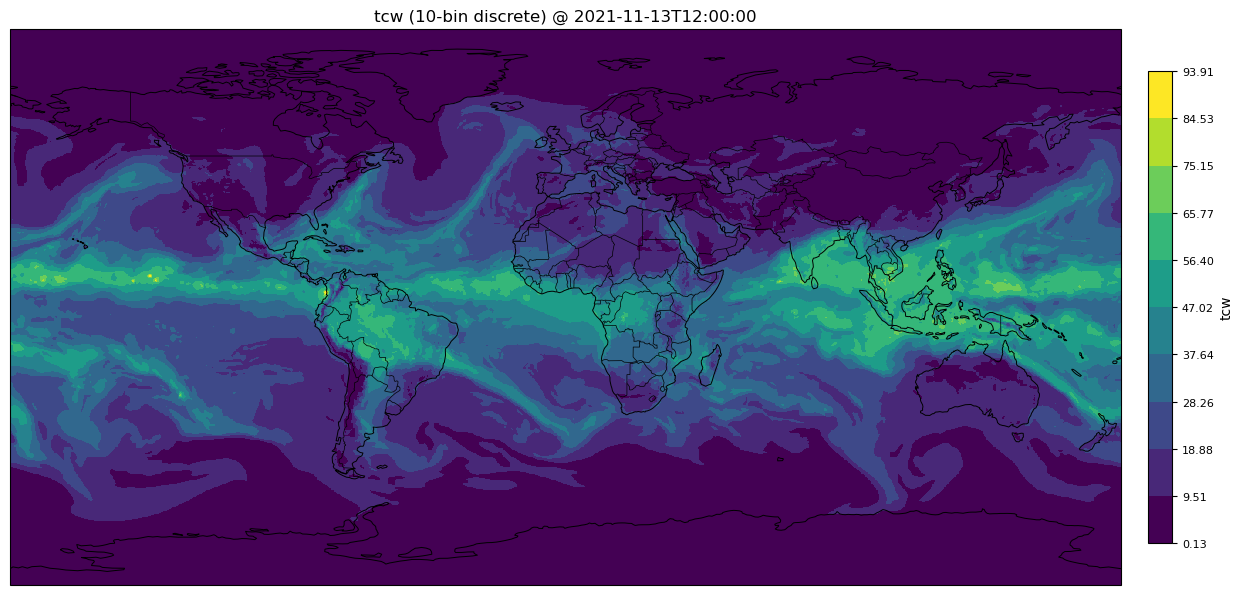

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- open dataset ----
PATH = "../data/waterTransport-instant.nc"
ds = xr.open_dataset(PATH)

# ---- select variable + time ----
da = ds["tcw"]
t = np.datetime64("2021-11-13T12:00:00")
tcw = da.sel(valid_time=t)

# ---- quick sanity prints ----
print("Dataset variables:", list(ds.data_vars))
print("Selected tcw shape:", tcw.shape)
print("tcw coords:", list(tcw.coords))

# ---- lon/lat ----
lon_name = "longitude" if "longitude" in tcw.coords else "lon"
lat_name = "latitude" if "latitude" in tcw.coords else "lat"

lon = tcw[lon_name].values
lat = tcw[lat_name].values
vals = tcw.values

# ---- discrete scale: 10 buckets across the data range ----
vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
levels = np.linspace(vmin, vmax, 11)  # 10 bins -> 11 edges
norm = mcolors.BoundaryNorm(levels, ncolors=256, clip=True)

print("vmin:", vmin, "vmax:", vmax)
print("bin edges:", levels)

# ---- plot ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(
    lon,
    lat,
    vals,
    transform=ccrs.PlateCarree(),
    norm=norm,
)

ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"tcw (10-bin discrete) @ {str(t)}")

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
cbar.set_label("tcw")
cbar.set_ticks(levels)            # show bin edges
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

Dataset variables: ['tcw']
Selected tcw shape: (721, 1440)
tcw coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
vmin: 0.12883156538009644 vmax: 93.90812683105469 mid: 18.807391679286958


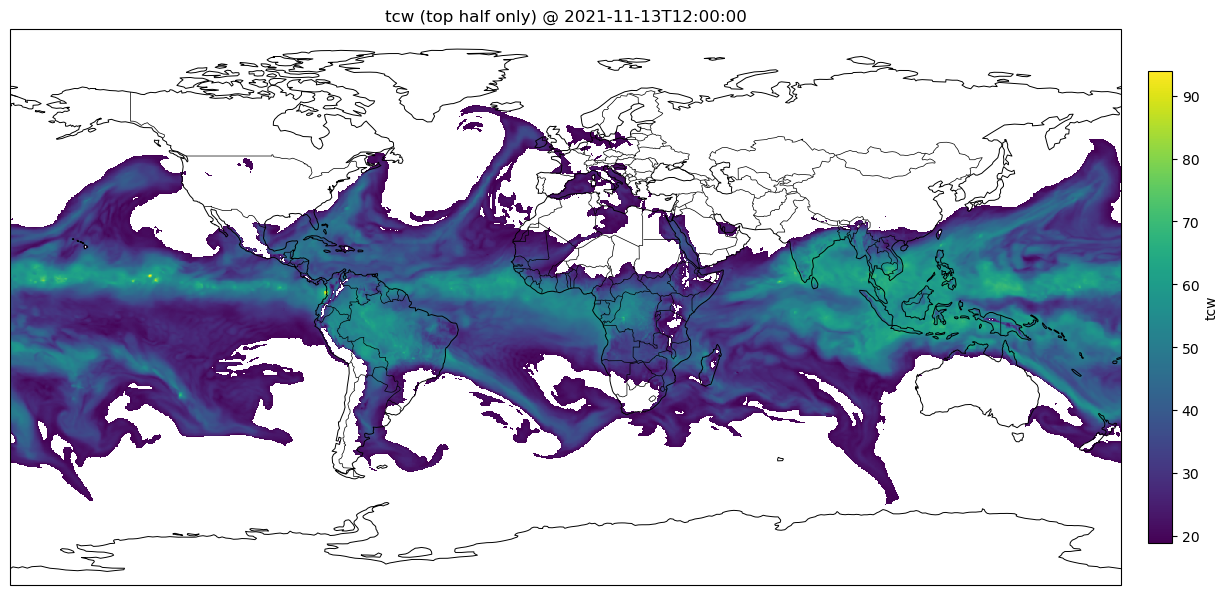

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- open dataset ----
PATH = "../data/waterTransport-instant.nc"
ds = xr.open_dataset(PATH)

# ---- select variable + time ----
da = ds["tcw"]
t = np.datetime64("2021-11-13T12:00:00")
tcw = da.sel(valid_time=t)

print("Dataset variables:", list(ds.data_vars))
print("Selected tcw shape:", tcw.shape)
print("tcw coords:", list(tcw.coords))

# ---- lon/lat ----
lon_name = "longitude" if "longitude" in tcw.coords else "lon"
lat_name = "latitude" if "latitude" in tcw.coords else "lat"

lon = tcw[lon_name].values
lat = tcw[lat_name].values
vals = tcw.values

# ---- show only top half of the range ----
vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
mid = 0.2 * (vmin + vmax)

# Mask out the bottom half entirely (won't be drawn)
vals_top = np.ma.masked_less(vals, mid)

# Continuous scale from mid -> vmax
norm = mcolors.Normalize(vmin=mid, vmax=vmax, clip=True)

print("vmin:", vmin, "vmax:", vmax, "mid:", mid)

# ---- plot ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(
    lon,
    lat,
    vals_top,
    transform=ccrs.PlateCarree(),
    norm=norm,
)

ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"tcw (top half only) @ {str(t)}")

plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.85, label="tcw")
plt.tight_layout()
plt.show()

TCW dataset variables: ['tcw']
Selected tcw shape: (721, 1440)
tcw coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Wind dataset variables: ['q', 'u', 'v']
Wind coords: ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
Product shape: (721, 1440)
Product coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'pressure_level']


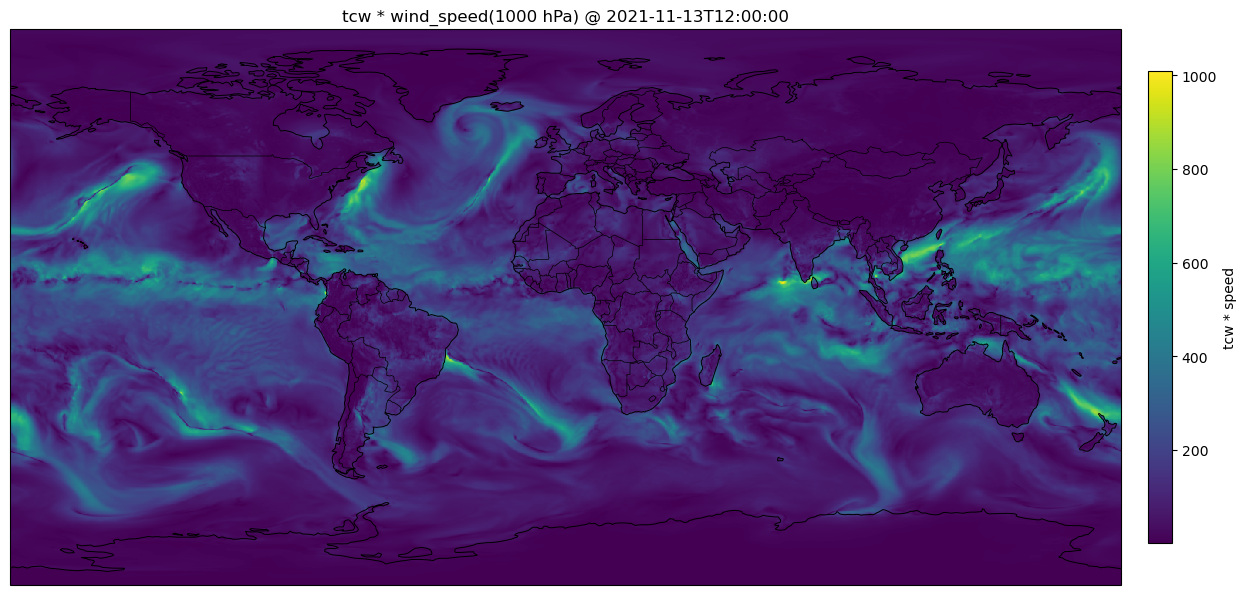

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# 1) Open TCW file + select time
# -----------------------------
TCW_PATH = "../data/waterTransport-instant.nc"
ds_tcw = xr.open_dataset(TCW_PATH)

tcw_da = ds_tcw["tcw"]
t = np.datetime64("2021-11-13T12:00:00")

tcw = tcw_da.sel(valid_time=t)

print("TCW dataset variables:", list(ds_tcw.data_vars))
print("Selected tcw shape:", tcw.shape)
print("tcw coords:", list(tcw.coords))

# lon/lat names (assumes tcw has lon/lat coords)
lon_name = "longitude" if "longitude" in tcw.coords else "lon"
lat_name = "latitude" if "latitude" in tcw.coords else "lat"

# -----------------------------
# 2) Open wind file + select 1000 hPa + same time
# -----------------------------
WIND_PATH = "../data/specifichumidity_wind_1000-925hpa_2026-02-19.nc"
ds_wind = xr.open_dataset(WIND_PATH)

print("Wind dataset variables:", list(ds_wind.data_vars))
print("Wind coords:", list(ds_wind.coords))

# Pick pressure coordinate name
level_name = "level" if "level" in ds_wind.coords else ("pressure_level" if "pressure_level" in ds_wind.coords else None)
if level_name is None:
    raise KeyError("Couldn't find a pressure coordinate (expected 'level' or 'pressure_level').")

# Pick time coordinate name
time_name = "valid_time" if "valid_time" in ds_wind.coords else ("time" if "time" in ds_wind.coords else None)
if time_name is None:
    raise KeyError("Couldn't find a time coordinate (expected 'valid_time' or 'time').")

# Try common u/v variable names
u_name = "u" if "u" in ds_wind.data_vars else ("u10" if "u10" in ds_wind.data_vars else None)
v_name = "v" if "v" in ds_wind.data_vars else ("v10" if "v10" in ds_wind.data_vars else None)
if u_name is None or v_name is None:
    raise KeyError("Couldn't find wind components (expected data vars like 'u'/'v' or 'u10'/'v10').")

u = ds_wind[u_name].sel({level_name: 1000, time_name: t})
v = ds_wind[v_name].sel({level_name: 1000, time_name: t})

# Wind speed
spd = np.hypot(u, v)

# -----------------------------
# 3) Multiply tcw * speed (align by coords)
# -----------------------------
# This will align on shared coordinates (lat/lon) if names/values match.
tcw_x_spd = tcw * spd

print("Product shape:", tcw_x_spd.shape)
print("Product coords:", list(tcw_x_spd.coords))

# -----------------------------
# 4) Plot tcw * speed
# -----------------------------
lon_name_p = "longitude" if "longitude" in tcw_x_spd.coords else "lon"
lat_name_p = "latitude" if "latitude" in tcw_x_spd.coords else "lat"

lon = tcw_x_spd[lon_name_p].values
lat = tcw_x_spd[lat_name_p].values
vals = tcw_x_spd.values

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(lon, lat, vals, transform=ccrs.PlateCarree())

ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"tcw * wind_speed(1000 hPa) @ {str(t)}")

plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.85, label="tcw * speed")
plt.tight_layout()
plt.show()

TCW dataset variables: ['tcw']
Selected tcw shape: (721, 1440)
tcw coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Wind dataset variables: ['q', 'u', 'v']
Wind coords: ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
Product shape: (721, 1440)
Product coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'pressure_level']


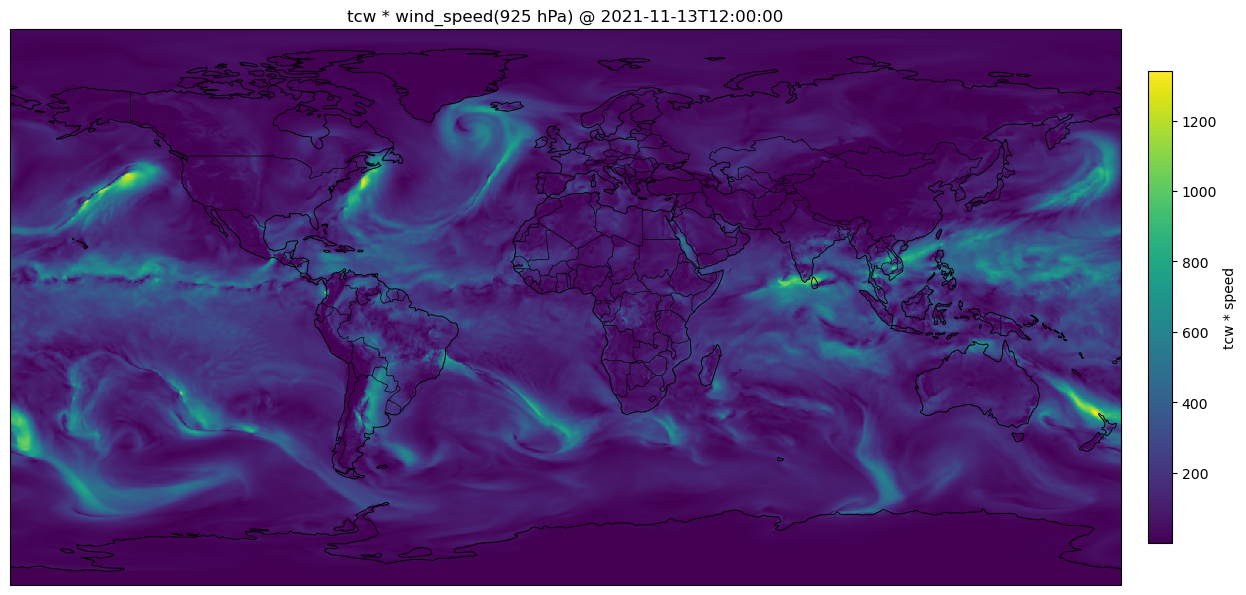

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# 1) Open TCW file + select time
# -----------------------------
TCW_PATH = "../data/waterTransport-instant.nc"
ds_tcw = xr.open_dataset(TCW_PATH)

tcw_da = ds_tcw["tcw"]
t = np.datetime64("2021-11-13T12:00:00")

tcw = tcw_da.sel(valid_time=t)

print("TCW dataset variables:", list(ds_tcw.data_vars))
print("Selected tcw shape:", tcw.shape)
print("tcw coords:", list(tcw.coords))

# -----------------------------
# 2) Open wind file + select 925 hPa + same time
# -----------------------------
WIND_PATH = "../data/specifichumidity_wind_1000-925hpa_2026-02-19.nc"
ds_wind = xr.open_dataset(WIND_PATH)

print("Wind dataset variables:", list(ds_wind.data_vars))
print("Wind coords:", list(ds_wind.coords))

level_name = "level" if "level" in ds_wind.coords else ("pressure_level" if "pressure_level" in ds_wind.coords else None)
if level_name is None:
    raise KeyError("Couldn't find a pressure coordinate (expected 'level' or 'pressure_level').")

time_name = "valid_time" if "valid_time" in ds_wind.coords else ("time" if "time" in ds_wind.coords else None)
if time_name is None:
    raise KeyError("Couldn't find a time coordinate (expected 'valid_time' or 'time').")

u_name = "u" if "u" in ds_wind.data_vars else ("u10" if "u10" in ds_wind.data_vars else None)
v_name = "v" if "v" in ds_wind.data_vars else ("v10" if "v10" in ds_wind.data_vars else None)
if u_name is None or v_name is None:
    raise KeyError("Couldn't find wind components (expected data vars like 'u'/'v' or 'u10'/'v10').")

u = ds_wind[u_name].sel({level_name: 925, time_name: t})
v = ds_wind[v_name].sel({level_name: 925, time_name: t})

spd = np.hypot(u, v)

# -----------------------------
# 3) Multiply tcw * speed (align by coords)
# -----------------------------
tcw_x_spd = tcw * spd

print("Product shape:", tcw_x_spd.shape)
print("Product coords:", list(tcw_x_spd.coords))

# -----------------------------
# 4) Plot tcw * speed
# -----------------------------
lon_name = "longitude" if "longitude" in tcw_x_spd.coords else "lon"
lat_name = "latitude" if "latitude" in tcw_x_spd.coords else "lat"

lon = tcw_x_spd[lon_name].values
lat = tcw_x_spd[lat_name].values
vals = tcw_x_spd.values

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(lon, lat, vals, transform=ccrs.PlateCarree())

ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"tcw * wind_speed(925 hPa) @ {str(t)}")

plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.85, label="tcw * speed")
plt.tight_layout()
plt.show()